In [1]:
%run utilities.ipynb 
load_standard_packages()
from matplotlib.lines import Line2D

Could not find cannot import name 'dopri5' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\modelbase\lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'rodas' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\modelbase\lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'odassl' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\modelbase\lib\site-packages\assimulo\lib\__init__.py)
Could not find ODEPACK functions.
Could not find RADAR5
Could not find GLIMDA.


1.58.0


# Testing protocols that are not DIRK and not PIRK

In [2]:
change_wordir()
import itertools as it
from tqdm import tqdm

In [3]:
analysis = "other"

colors, colours = colourblind_palette("own")

#model = "cyclic_2021"
#model = "cyclic_2021_ODE"
#model = "new_PSI"
#model = "new_PSII"
#model = "new_b6f"
model = "latest_dev"

m = load_model(model)


succesfully loaded latest_dev :D


In [4]:
# I like to have light as a derived variable
m.add_algebraic_module(module_name = "Light",
    function = lambda X, PFD: PFD, # X is not used
    compounds = ["PQ"], derived_compounds = ["L"], parameters = ['pfd'])

In [5]:
y0 = get_stst_y0(m, pfd=35)

s = Simulator(m)
s.initialise(y0)

In [8]:
def simulate_change():
    """
    Simulate a change in a parameter from value1 to value2, starting at 0. Change appears at "t_to_0".
    """
    #get steady state
    s.update_parameter("pfd", 30)
    s.initialise(y0)
    s.simulate_to_steady_state()
    y1 = s.get_new_y0()
    if y1 is None:
        # throw error if steady state not reached
        raise ValueError("Modelbase says NO")

    # include some seconds before change
    s.initialise(y1)
    s.simulate(2)

    # simulate change
    s.update_parameter("pfd", 400)
    s.simulate(11)

    # simulate change
    s.update_parameter("pfd", 30)
    s.simulate(30)
    
    return None

In [9]:
# DARK TO LIGHT TRANSITION

simulate_change()

c = s.get_full_results_df()

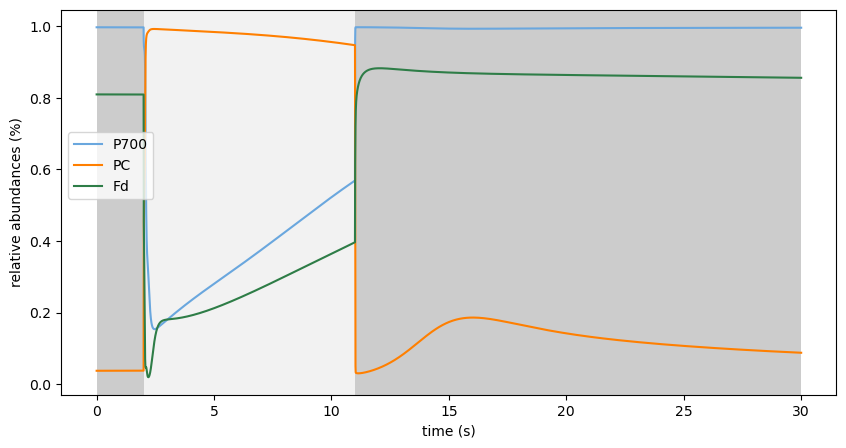

In [12]:
# PLOT PSI STATES

fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
#ax2 = ax1.twinx()

ax1.plot(c["rel_P700"], label="P700", color=colors[0])
ax1.plot(1-c["PC_redoxstate"], label="PC", color=colors[1])
ax1.plot(1-c["Fd_redoxstate"], label="Fd", color =colors[2])

shade_light(c, (ax1))

ax1.set(#xlim=t_borders,
        #xlim=(4.99, 6),
        #ylim=(-0.00, 1),
        xlabel=("time (s)"),
        ylabel=("relative abundances (%)"))
ax2.set(#ylim=(-0.0, 0.03)
    )

#legends
ax1.legend(loc="upper left", bbox_to_anchor=(0, 0.7))
ax2.legend(loc = "upper right", bbox_to_anchor=(1, 1))
